# **Customer Support Ticket Categorisation**

## **Project Overview**
This project aims to build an end-to-end NLP pipeline to automatically categorize customer support tickets into four main categories: Technical, Billing, Account, and Other. By leveraging Machine Learning and Large Language Models (LLMs), the system identifies the nature of a problem from the ticket's subject and body to streamline support workflows.


## *Dataset :*

[https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset](https://)

## *Columns :*
- Ticket ID: A unique identifier for each ticket.

- Customer Name: The name of the customer who raised the ticket.

- Customer Email: The email address of the customer (Domain name - @example.com is intentional for user data privacy concern).

- Customer Age: The age of the customer.

- Customer Gender: The gender of the customer.

- Product Purchased: The tech product purchased by the customer.

- Date of Purchase: The date when the product was purchased.

- Ticket Type: The type of ticket (e.g., technical issue, billing inquiry, product inquiry).

- Ticket Subject: The subject/topic of the ticket.

- Ticket Description: The description of the customer's issue or inquiry.

- Ticket Status: The status of the ticket (e.g., open, closed, pending customer response).

- Resolution: The resolution or solution provided for closed tickets.

- Ticket Priority: The priority level assigned to the ticket (e.g., low, medium, high, critical).

- Ticket Channel: The channel through which the ticket was raised (e.g., email, phone, chat, social media).

- First Response Time: The time taken to provide the first response to the customer.

- Time to Resolution: The time taken to resolve the ticket.

- Customer Satisfaction Rating: The customer's satisfaction rating for closed tickets (on a scale of 1 to 5).

## *Loading Dataset*

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-support-ticket-dataset' dataset.
Path to dataset files: /kaggle/input/customer-support-ticket-dataset


In [2]:
path

'/kaggle/input/customer-support-ticket-dataset'

In [3]:
# Read the dataset

import pandas as pd
import os
data = pd.read_csv(os.path.join(path, 'customer_support_tickets.csv'))
data.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## *Visualization & Analysiss*

## **1. Data Understanding**

In [4]:
# Dataset shape (rows, columns)

data.shape

(8469, 17)

In [5]:
# Data Types

data.dtypes

,0
Ticket ID,int64
Customer Name,object
Customer Email,object
Customer Age,int64
Customer Gender,object
Product Purchased,object
Date of Purchase,object
Ticket Type,object
Ticket Subject,object
Ticket Description,object


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [7]:
# Missing Values Analysis

data.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [8]:
# Duplicate samples check

data.duplicated().sum()

np.int64(0)

In [9]:
# Basic statistics

data.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [10]:
data.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## **2. Target / Label Analysis**

In [11]:
target_col = ['Ticket Type']
data[target_col].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


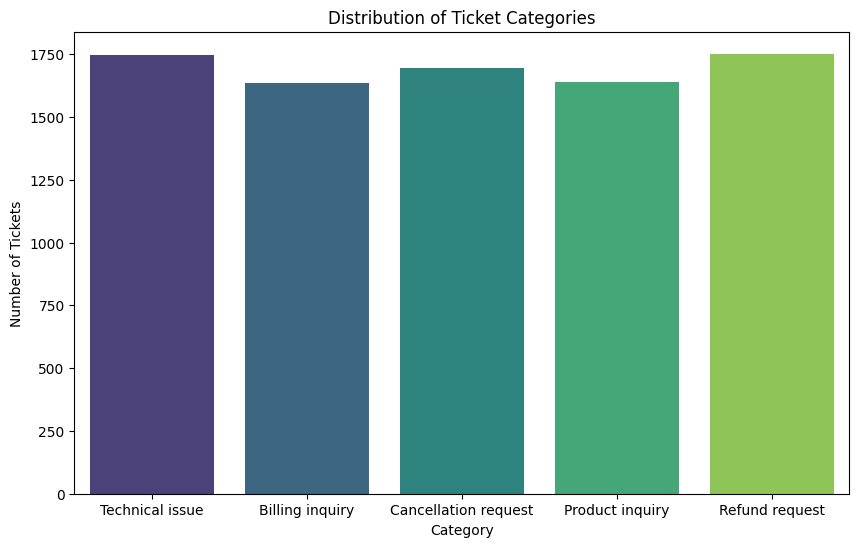

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'Ticket Type'
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x=target_col, hue=target_col, palette='viridis', legend=False)
plt.title('Distribution of Ticket Categories')
plt.xlabel('Category')
plt.ylabel('Number of Tickets')

plt.show()

In [13]:
# Check imbalance

(data[target_col].value_counts(normalize=True) * 100).round(2).astype(str) + '%'


,proportion
Ticket Type,
Refund request,20.69%
Technical issue,20.63%
Cancellation request,20.01%
Product inquiry,19.38%
Billing inquiry,19.29%


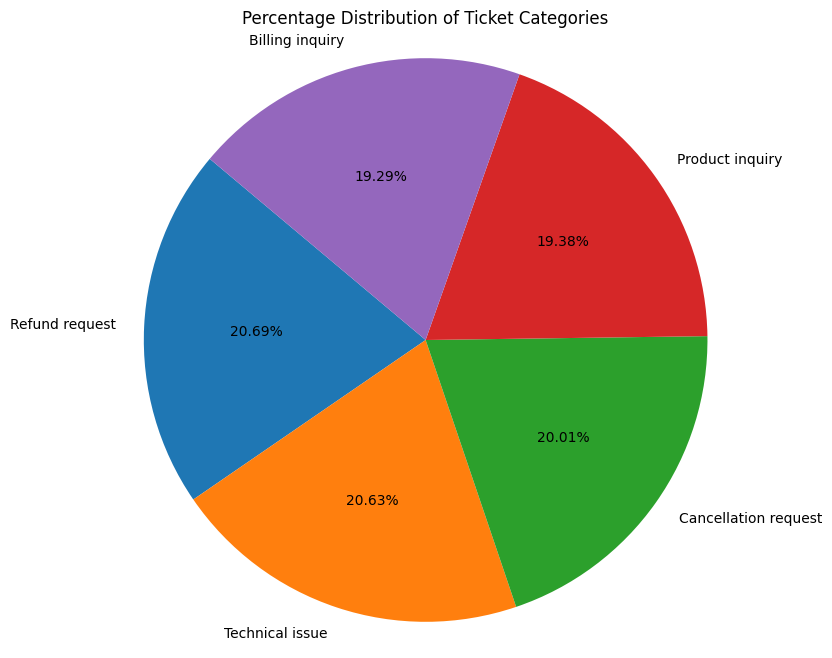

In [14]:
# Pie Chart

target_counts = data[target_col].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.2f%%',
        startangle=140)

plt.title('Percentage Distribution of Ticket Categories')
plt.axis('equal')
plt.show()

## **3. Feature Analysis**

### ***Numerical Features***

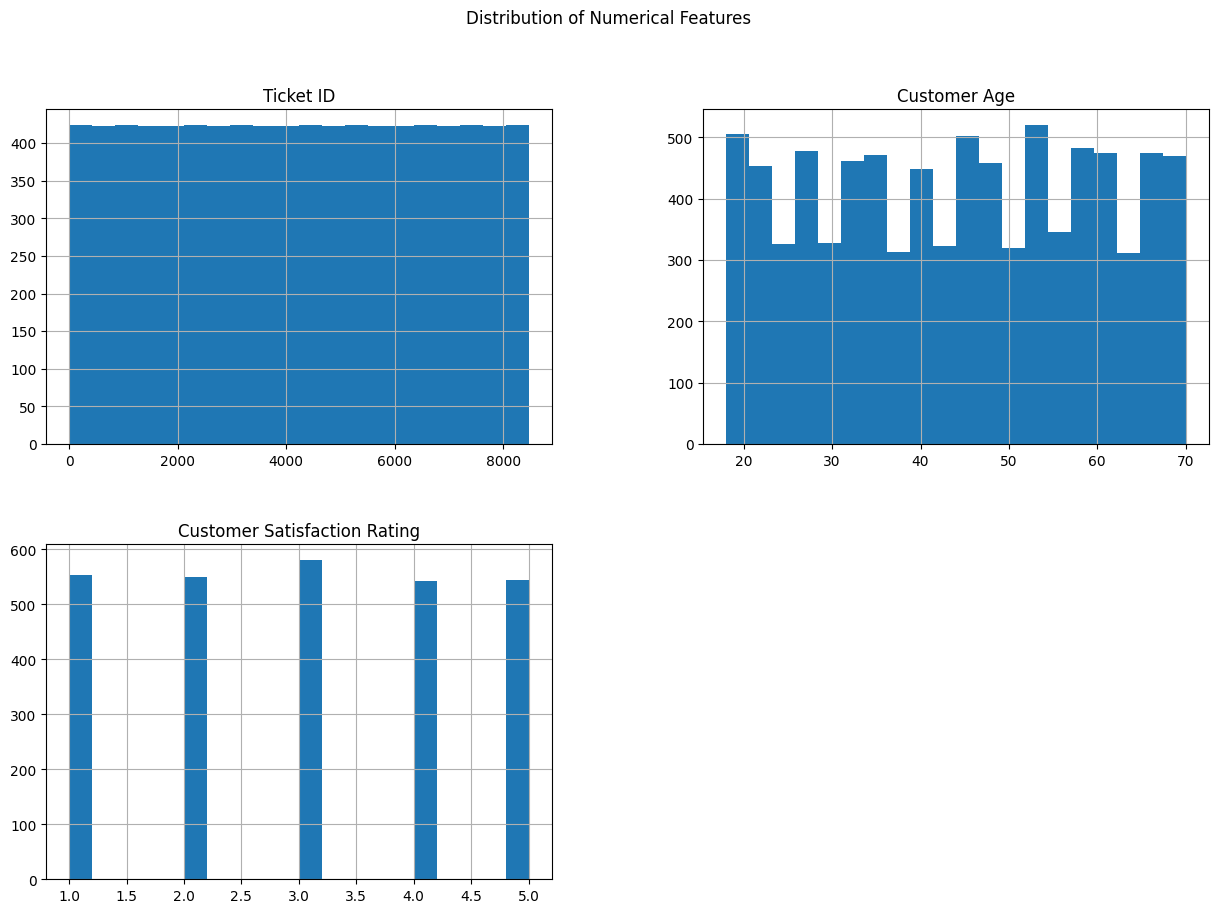

In [15]:
# Distribution plots (Histogram )

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

if len(numerical_cols) > 0:
    data[numerical_cols].hist(bins=20, figsize=(15, 10))
    plt.suptitle('Distribution of Numerical Features')
    plt.show()

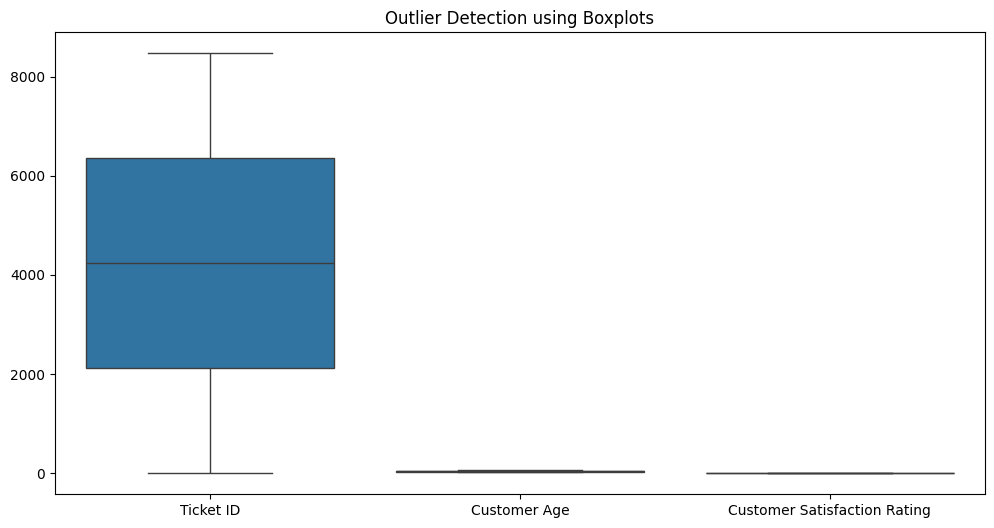

In [16]:
# Boxplots (outlier detection)

plt.figure(figsize=(12, 6))
sns.boxplot(data=data[numerical_cols])
plt.title('Outlier Detection using Boxplots')
plt.show()

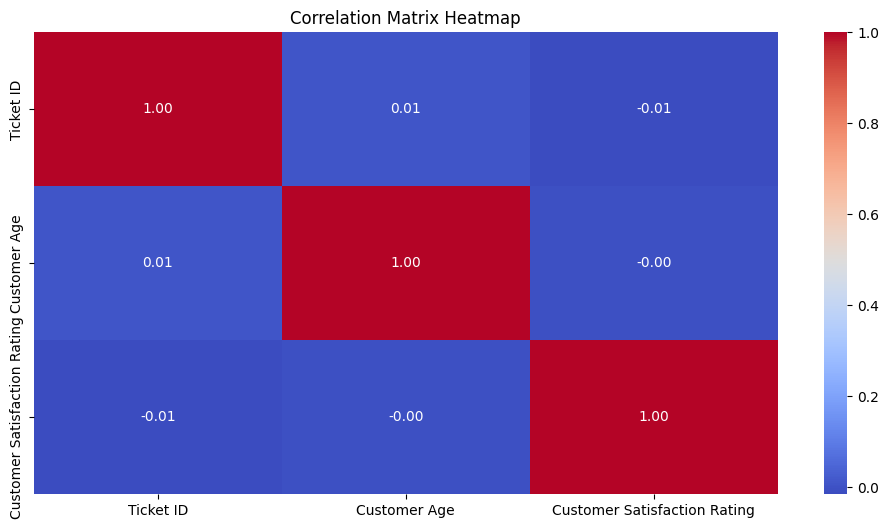

In [17]:
# Correlation matrix heatmap

plt.figure(figsize=(12, 6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

### ***Categorical Features***

/tmp/ipykernel_1845/276738276.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='magma', order=data[col].value_counts().index)


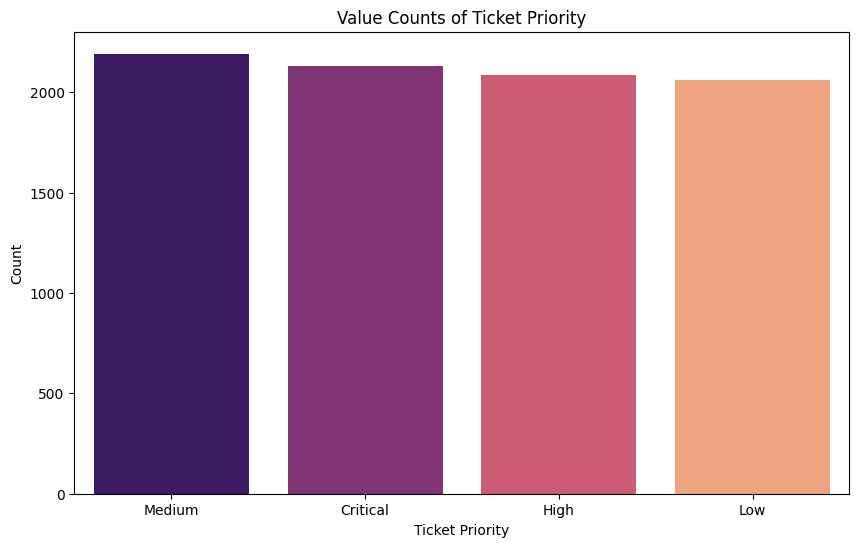

/tmp/ipykernel_1845/276738276.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='magma', order=data[col].value_counts().index)


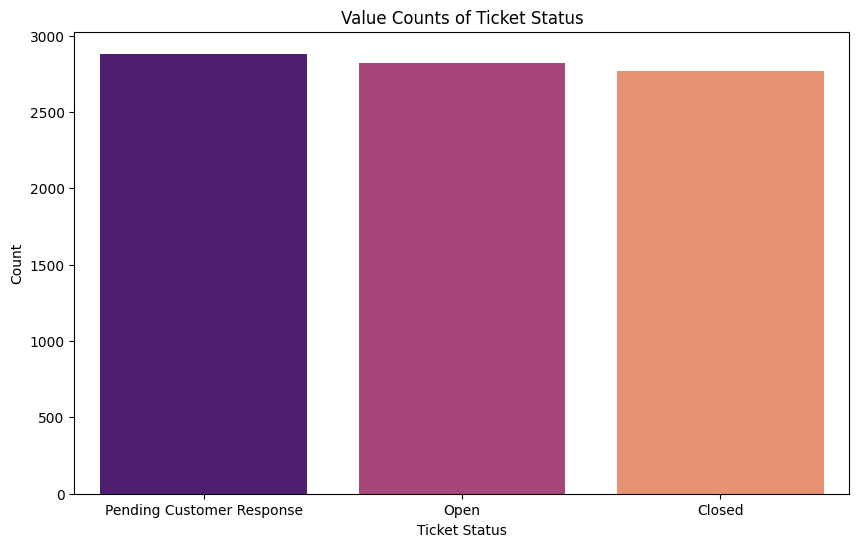

/tmp/ipykernel_1845/276738276.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='magma', order=data[col].value_counts().index)


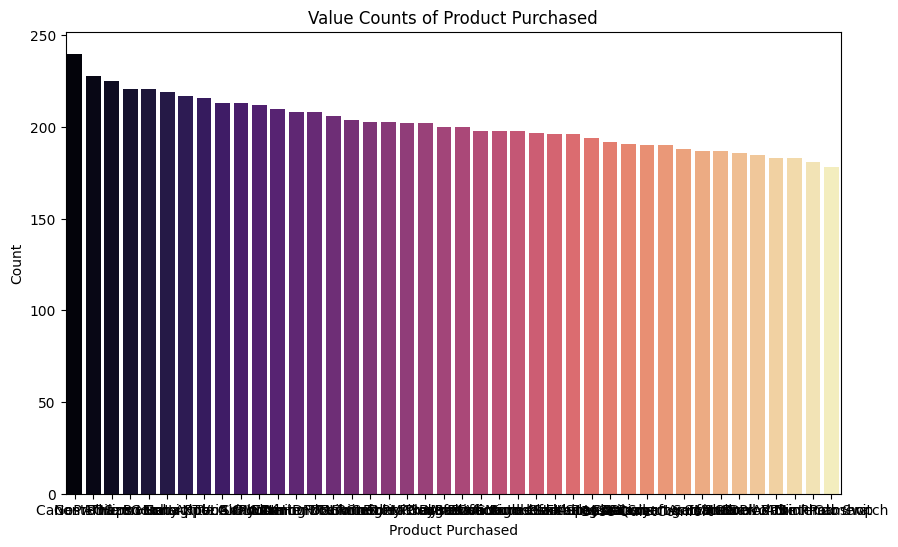

In [18]:
# Value counts (bar chart)

categorical_cols = ['Ticket Priority', 'Ticket Status', 'Product Purchased']

for col in categorical_cols:
    if col in data.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=data, x=col, palette='magma', order=data[col].value_counts().index)
        plt.title(f'Value Counts of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

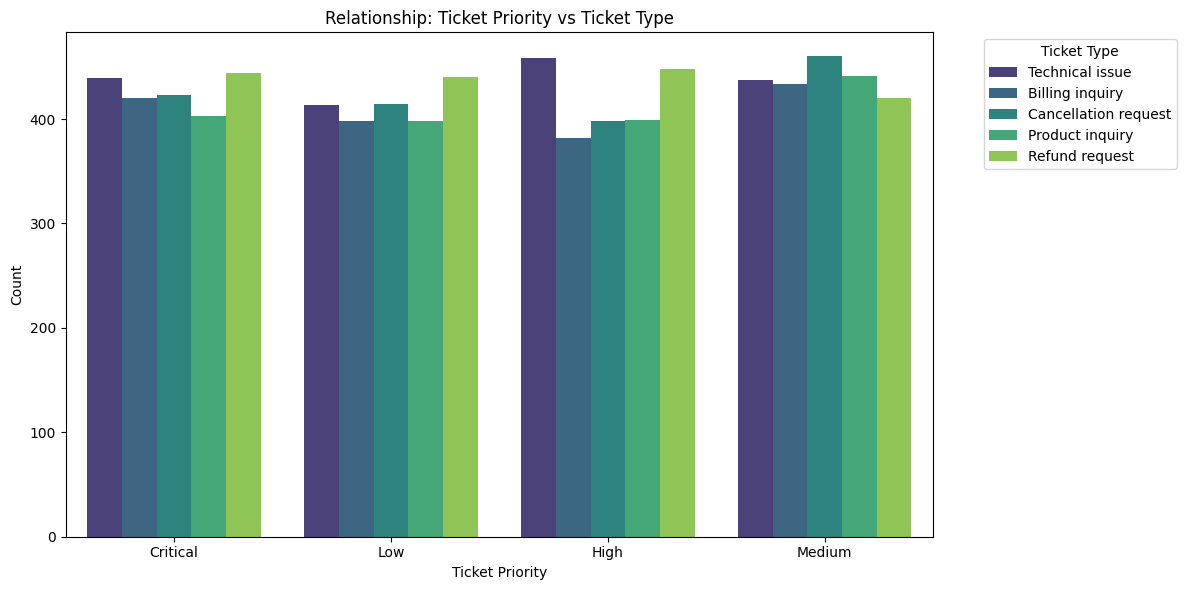

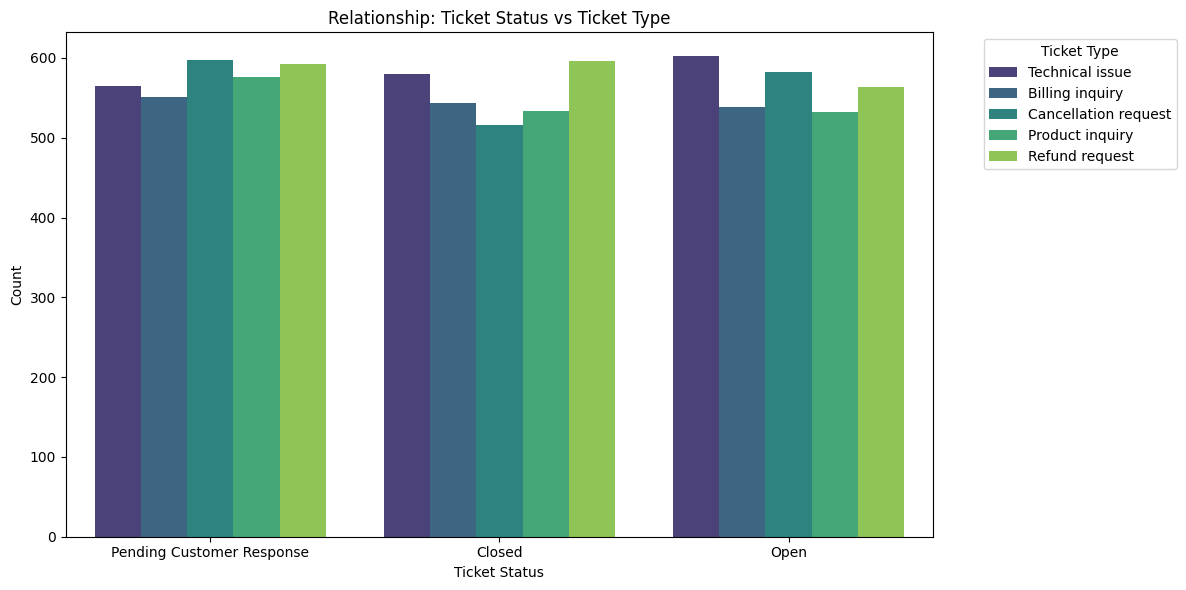

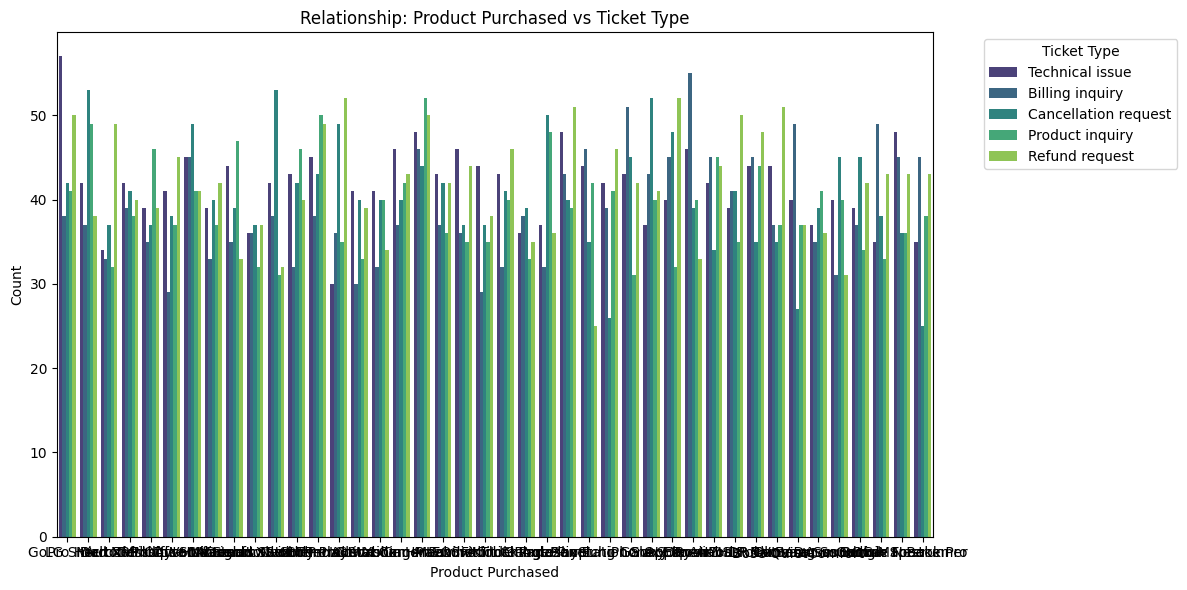

In [19]:
# Category vs target relationship (grouped bar chart)

for col in categorical_cols:
    if col in data.columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=col, hue='Ticket Type', palette='viridis')
        plt.title(f'Relationship: {col} vs Ticket Type')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.legend(title='Ticket Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

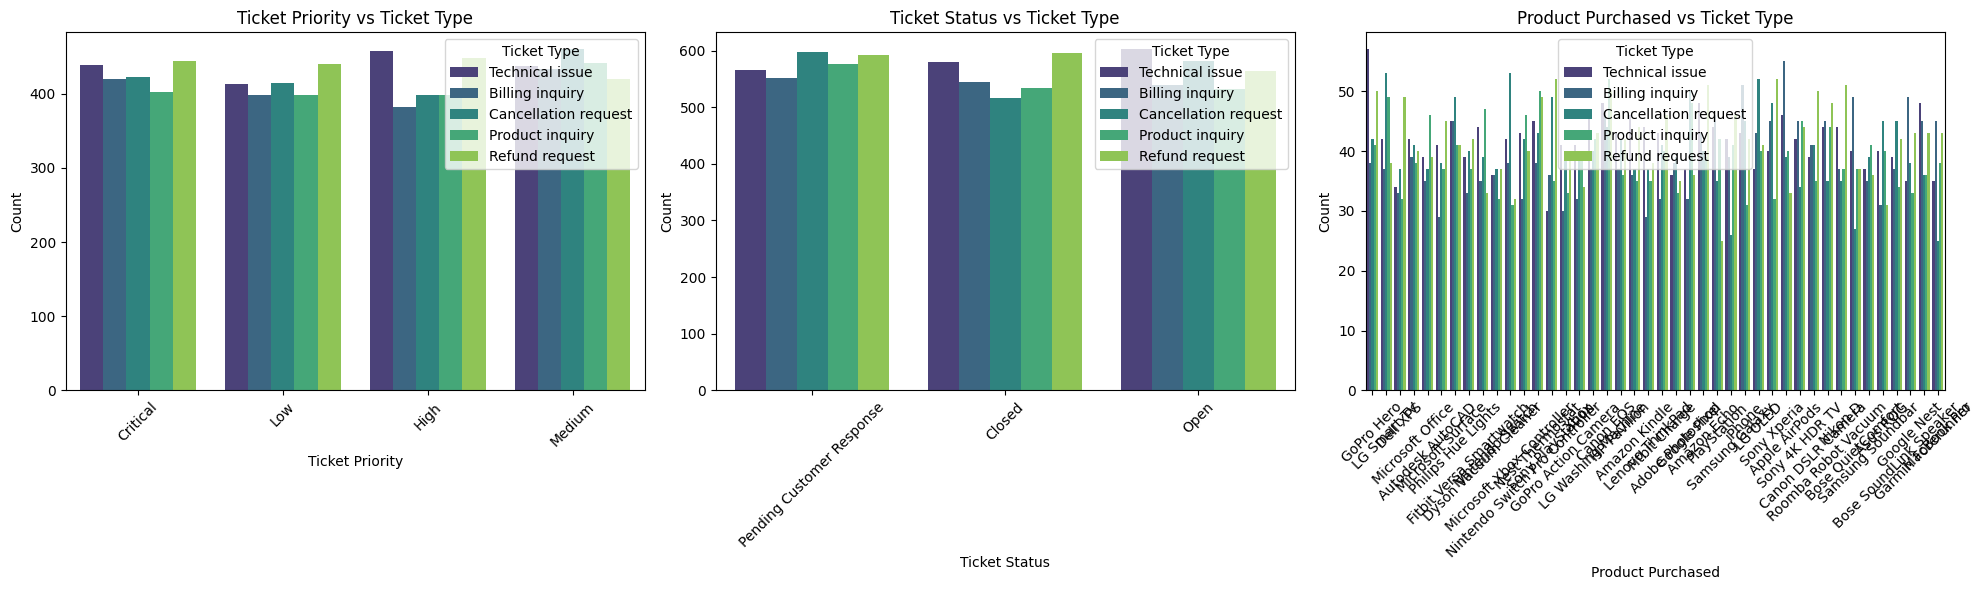

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=len(categorical_cols), figsize=(20, 6))

for i, col in enumerate(categorical_cols):
    if col in data.columns:
        sns.countplot(data=data, x=col, hue='Ticket Type', palette='viridis', ax=axes[i])
        axes[i].set_title(f'{col} vs Ticket Type')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

### ***Text Data***

In [21]:
data

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


In [22]:
# Preparing the input

data['input'] = data['Ticket Subject'] + ' ' + data['Ticket Description']
data['input']

,input
0,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility I'm having an issue w...
2,Network problem I'm facing a problem with my {...
3,Account access I'm having an issue with the {p...
4,Data loss I'm having an issue with the {produc...
...,...
8464,Installation support My {product_purchased} is...
8465,Refund request I'm having an issue with the {p...
8466,Account access I'm having an issue with the {p...
8467,Payment issue I'm having an issue with the {pr...


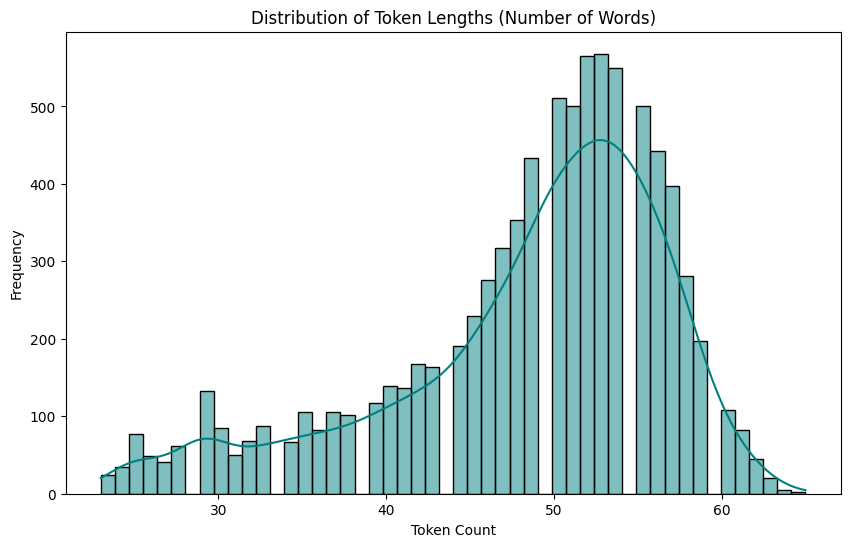

In [23]:
# Token length distribution

data['token_length'] = data['input'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data['token_length'], bins=50, kde=True, color='teal')
plt.title('Distribution of Token Lengths (Number of Words)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.show()

In [24]:
!pip install nltk

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


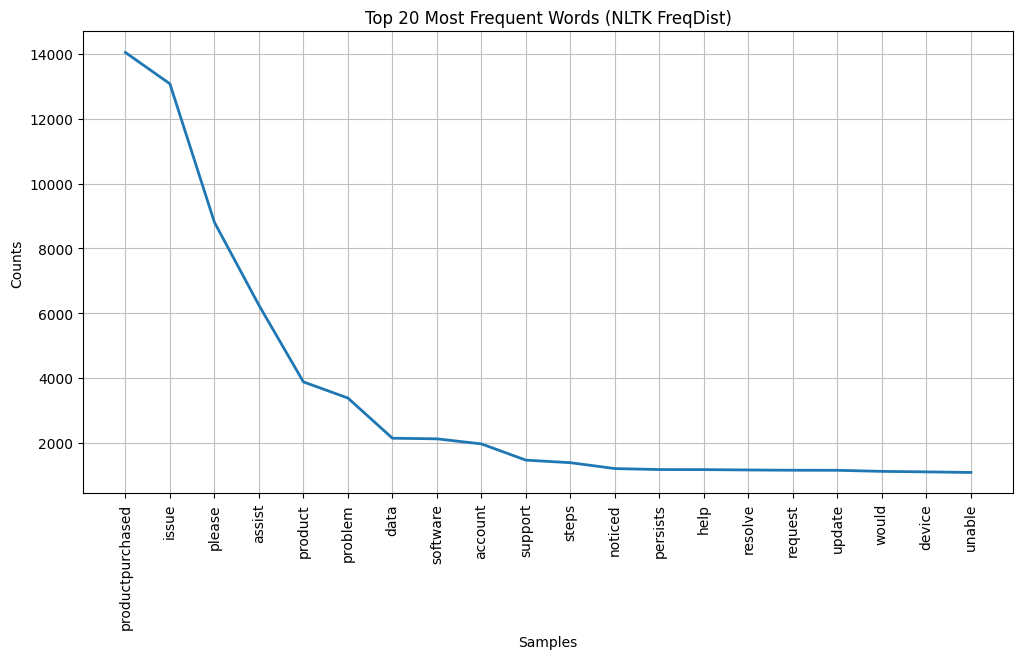

In [25]:
# Most frequent words (top N)

import nltk
from nltk.probability import FreqDist
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def get_clean_words(text_series):
    words = " ".join(text_series.astype(str)).lower().split()
    return [re.sub(r'[^a-z]', '', w) for w in words if w not in stop_words and len(re.sub(r'[^a-z]', '', w)) > 2]

all_clean_words = get_clean_words(data['input'])
fdist = FreqDist(all_clean_words)

plt.figure(figsize=(12, 6))
fdist.plot(20, title='Top 20 Most Frequent Words (NLTK FreqDist)')
plt.show()

In [26]:
!pip install wordcloud

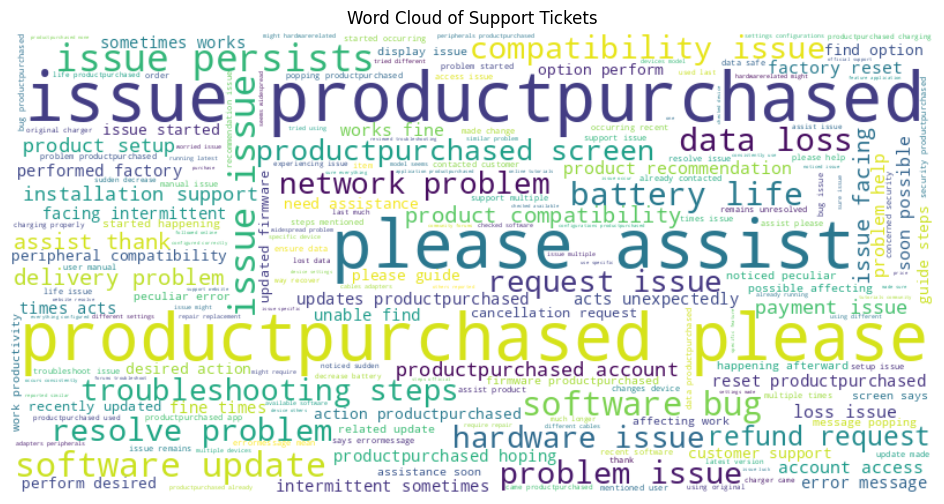

In [27]:
# Word cloud (optional)

from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(all_clean_words))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Support Tickets')
plt.show()

/tmp/ipykernel_1845/210557238.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(labels), palette='magma')


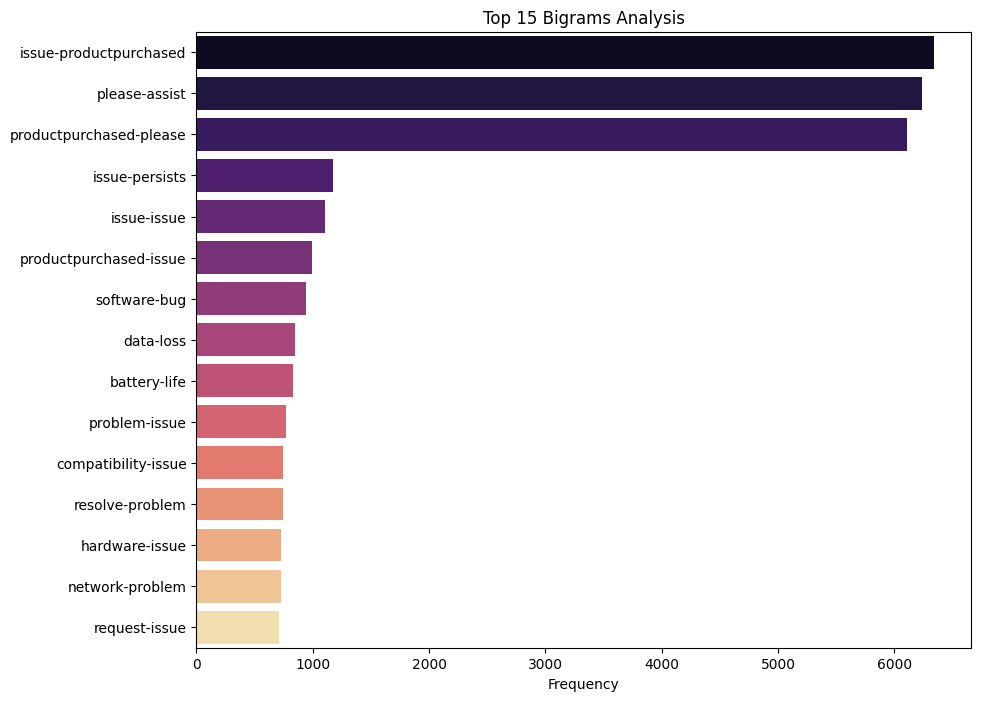

In [28]:
# N-grams analysis

from nltk.util import ngrams
from collections import Counter

bigrams = list(ngrams(all_clean_words, 2))
bigram_counts = Counter(bigrams)

top_bigrams = bigram_counts.most_common(15)
labels, counts = zip(*[("-".join(bg), c) for bg, c in top_bigrams])

plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(labels), palette='magma')
plt.title('Top 15 Bigrams Analysis')
plt.xlabel('Frequency')
plt.show()

## **4. Data Quality Checks**

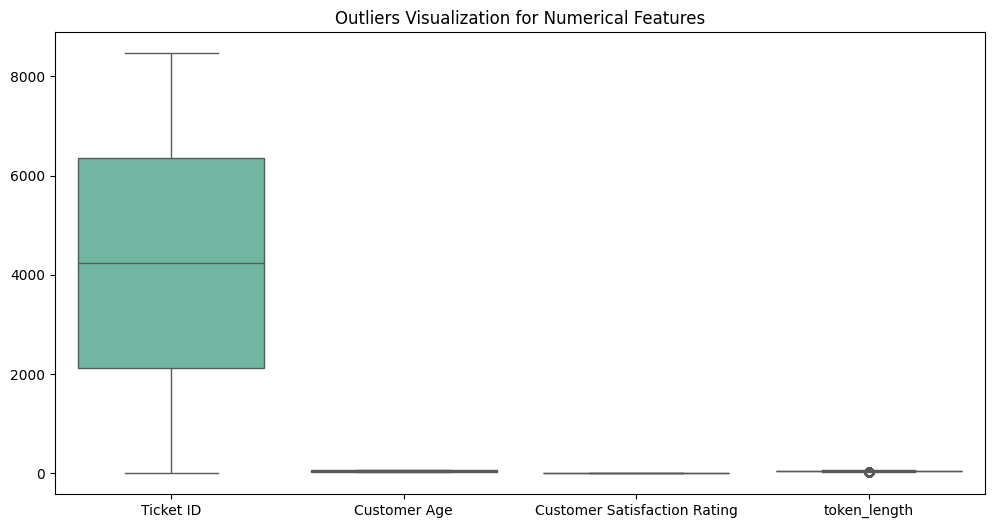

In [29]:
# Outliers visualization

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

if len(numerical_cols) > 0:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data[numerical_cols], palette='Set2')
    plt.title('Outliers Visualization for Numerical Features')
    plt.show()

Skewness Detection Results:
Ticket ID                       0.000000
Customer Age                   -0.017172
Customer Satisfaction Rating    0.008370
token_length                   -1.029582
dtype: float64


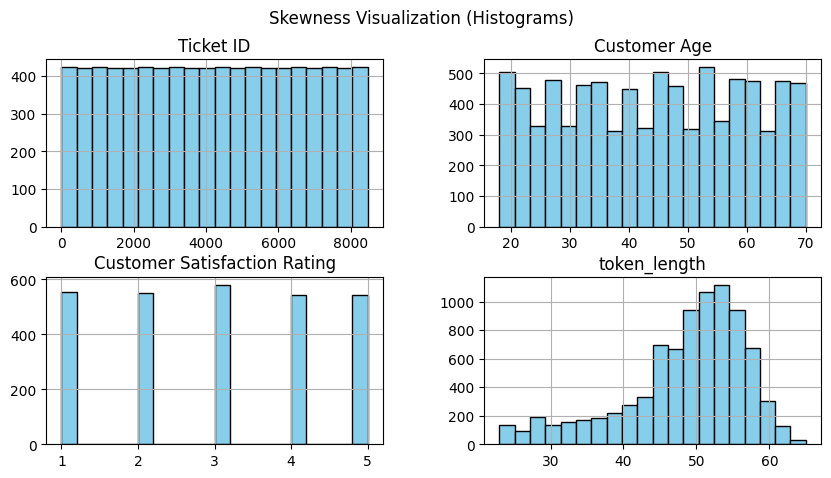

In [30]:
# Skewness detection

if len(numerical_cols) > 0:
    print("Skewness Detection Results:")
    skew_values = data[numerical_cols].skew()
    print(skew_values)

    data[numerical_cols].hist(bins=20, figsize=(10, 5), color='skyblue', edgecolor='black')
    plt.suptitle('Skewness Visualization (Histograms)')
    plt.show()

In [31]:
# Feature scaling need

if len(numerical_cols) > 0:
    scaling_check = data[numerical_cols].describe().loc[['min', 'max', 'mean']]
    print("Feature Scaling Needs Analysis:")
    print(scaling_check)

Feature Scaling Needs Analysis:
      Ticket ID  Customer Age  Customer Satisfaction Rating  token_length
min         1.0     18.000000                      1.000000     23.000000
max      8469.0     70.000000                      5.000000     65.000000
mean     4235.0     44.026804                      2.991333     48.467352


In [32]:
# Noise / anomalies inspection

print("Noise Inspection (Sample Text):")
print(data['input'].sample(5).values)

categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'text_input':
        print(f"\nUnique values in {col}: {data[col].nunique()}")

Noise Inspection (Sample Text):
["Product recommendation I'm having trouble connecting my {product_purchased} to my home Wi-Fi network. It doesn't detect any networks, although other devices are connecting fine. What can be done to resolve this issue?\n\nI can try to I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer."
 "Network problem I'm having an issue with the {product_purchased}. Please assist. {sommer}.\n\nI am getting a refund for the {product_purchased} from the company you were buying, and you have not requested I've noticed that the issue occurs consistently when I use a specific feature or application on my {product_purchased}."
 "Network problem I'm having an issue with the {product_purchased}. Please assist.\n\nThe {product_purchased}. Please assist. All items are fully refunded once we have received their price and delivery information.\n\n\nIf you I've noticed that the issue occurs consistently when I use a specific fea

## **5. Pre-processing**

In [33]:
# Drop unimportant columns

cols_to_drop = [
    'Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
    'Customer Gender', 'Customer Satisfaction Rating', 'Time to Resolution',
    'Resolution', 'First Response Time']

data.drop(columns=cols_to_drop, axis=1, inplace=True)

print("Columns are deleted")
print(data.columns.tolist())

Columns are deleted
['Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Ticket Priority', 'Ticket Channel', 'input', 'token_length']


In [34]:
# Categories in target column

print(data['Ticket Type'].value_counts())


label_map = {
    'Technical issue':      'Technical',
    'Technical Issue':      'Technical',
    'Billing inquiry':      'Billing',
    'Billing Inquiry':      'Billing',
    'Account access':       'Account',
    'Account Access':       'Account',
    'Product inquiry':      'Other',
    'Product Inquiry':      'Other',
    'Refund request':       'Billing',
    'Cancellation request': 'Billing',
    'Shipping issue':       'Other',
    'Other':                'Other',
}

data['Label'] = data['Ticket Type'].map(label_map)

print("\nAfter mapping:")
print(data['Label'].value_counts())
print("NaN values:", data['Label'].isnull().sum())

data = data.dropna(subset=['Label'])

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

After mapping:
Label
Billing      5081
Technical    1747
Other        1641
Name: count, dtype: int64
NaN values: 0


In [35]:
# Prepare Liberaries

import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [36]:
# Function to Preprocessing

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)


In [38]:
data['text_clean'] = data['input'].apply(clean_text)

print("Example of the text before cleaning :")
print(data['input'].iloc[0][:200])
print("\nExample of the text after cleaning :")
print(data['text_clean'].iloc[0][:200])

Example of the text before cleaning :
Product setup I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your ema

Example of the text after cleaning :
product setup issue product purchased please assist billing zip code appreciate requested website address please double check email address tried troubleshooting step mentioned user manual issue persi


## **6. Representation**

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),   # unigrams + bigrams
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(data['text_clean'])
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 6775
Test size: 1694


## **7. ML Models**

In [41]:
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [42]:
# Label Encoding

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [43]:
# Helper Function

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import joblib

def train_and_evaluate(name, model, X_train, y_train, X_test, y_test, is_nlp=True):
    print(f"\n Training {name}")

    needs_dense = ['KNN', 'ADA']
    if any(x in name for x in needs_dense):
        from scipy.sparse import issparse
        X_tr = X_train.toarray() if issparse(X_train) else X_train
        X_te = X_test.toarray() if issparse(X_test) else X_test
    else:
        X_tr, X_te = X_train, X_test

    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Display Results
    results_dict = {
        'Metric': ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-score (Weighted)'],
        'Value (%)': [f"{acc*100:.2f}%", f"{precision*100:.2f}%", f"{recall*100:.2f}%", f"{f1*100:.2f}%"]
    }
    display(pd.DataFrame(results_dict))

    # Classification Report
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))

    return y_pred, acc

# Confusion Matrix
def plot_conf_matrix(y_test, y_pred, name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [45]:
from sklearn.naive_bayes import MultinomialNB

# Models Dictionary

all_models = {
    # ================= Logistic Regression =================
    'LR_1': LogisticRegression(C=1, max_iter=1000, class_weight='balanced'),

    'LR_2': LogisticRegression(C=5, max_iter=2000, class_weight='balanced', solver='lbfgs', multi_class='multinomial'),

    'LR_3': LogisticRegression(C=10, max_iter=3000, class_weight='balanced'),

    # ================= LinearSVC =================
    'SVC_1': LinearSVC(C=0.1, max_iter=3000, class_weight='balanced'),

    'SVC_2': LinearSVC(C=1, max_iter=5000, class_weight='balanced'),

    'SVC_3': LinearSVC(C=2, max_iter=7000, class_weight='balanced'),

    # ================= SGD =================
    'SGD_1': SGDClassifier(loss='hinge', alpha=0.0001, max_iter=1000,random_state=42),

    'SGD_2': SGDClassifier(loss='log_loss', alpha=0.0001, max_iter=1500, class_weight='balanced', random_state=42),

    'SGD_3': SGDClassifier(loss='modified_huber', alpha=0.0001, max_iter=2000, class_weight='balanced', random_state=42),

    'SGD_4': SGDClassifier(loss='perceptron', alpha=0.001, max_iter=3000, random_state=42),

    # ================= Complement NB =================
    'CNB_1': ComplementNB(alpha=1.0),

    'CNB_2': ComplementNB(alpha=0.5),

    'CNB_3': ComplementNB(alpha=0.1),

    'CNB_4': ComplementNB(alpha=0.05),

    # ================= Multinomial NB =================
    'MNB_1': MultinomialNB(alpha=1.0),

    'MNB_2': MultinomialNB(alpha=0.5),

    'MNB_3': MultinomialNB(alpha=0.1),

    'MNB_4': MultinomialNB(alpha=0.01),

    # ================= Random Forest =================

    'RF_1': RandomForestClassifier(n_estimators=100, max_depth=20,random_state=42, n_jobs=-1),

    'RF_2': RandomForestClassifier(
        n_estimators=300,max_depth=None, class_weight='balanced', random_state=42, n_jobs=-1),

    'RF_3': RandomForestClassifier(
        n_estimators=500,max_depth=None, min_samples_split=2,class_weight='balanced',random_state=42, n_jobs=-1),

    # ================= XGBoost =================
    'XGB_1': XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, eval_metric='mlogloss',random_state=42),

    'XGB_2': XGBClassifier(
        n_estimators=300, max_depth=6,learning_rate=0.05, subsample=0.9,
        colsample_bytree=0.9, eval_metric='mlogloss',random_state=42),

    'XGB_3': XGBClassifier(
        n_estimators=500, max_depth=8, learning_rate=0.03, subsample=1,
        colsample_bytree=1, eval_metric='mlogloss', random_state=42),

    # ================= Gradient Boosting =================
    'GB_1': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),

    'GB_2': GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=42),

    # ================= Decision Tree =================
    'DT_1': DecisionTreeClassifier(max_depth=10, random_state=42),

    'DT_2': DecisionTreeClassifier(max_depth=20, min_samples_split=5, class_weight='balanced', random_state=42),

    # ================= AdaBoost =================
    'ADA_1': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, learning_rate=1.0, random_state=42),

    'ADA_2': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=200, learning_rate=0.5, random_state=42),

    # ================= KNN =================
    'KNN_1': KNeighborsClassifier(
        n_neighbors=3, metric='cosine', algorithm='brute', n_jobs=-1),

    'KNN_2': KNeighborsClassifier(
        n_neighbors=5, metric='cosine', algorithm='brute', n_jobs=-1),

    'KNN_3': KNeighborsClassifier(
        n_neighbors=7, metric='cosine', algorithm='brute', n_jobs=-1),
}


 Training LR_1


,Metric,Value (%)
0,Accuracy,38.55%
1,Precision (Weighted),43.72%
2,Recall (Weighted),38.55%
3,F1-score (Weighted),40.45%



Classification Report for LR_1:
              precision    recall  f1-score   support

     Billing       0.59      0.46      0.52      1016
       Other       0.21      0.27      0.24       328
   Technical       0.20      0.27      0.23       350

    accuracy                           0.39      1694
   macro avg       0.33      0.33      0.33      1694
weighted avg       0.44      0.39      0.40      1694

New Champion for LR! Model LR_1 saved with accuracy: 38.55%


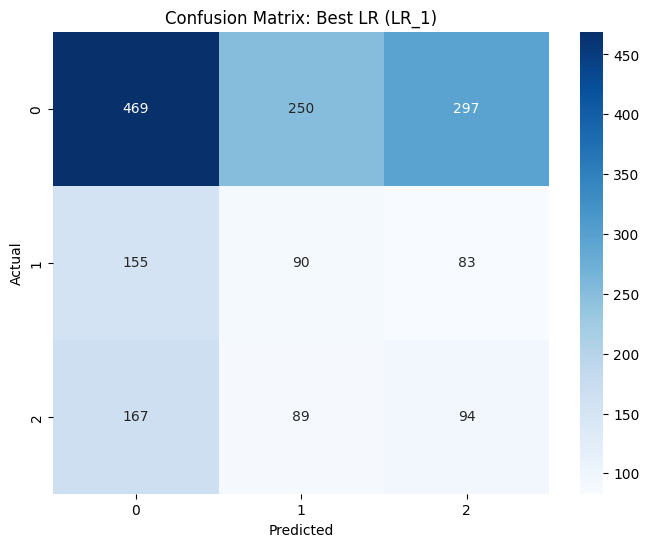


 Training LR_2


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Metric,Value (%)
0,Accuracy,40.67%
1,Precision (Weighted),43.87%
2,Recall (Weighted),40.67%
3,F1-score (Weighted),42.01%



Classification Report for LR_2:
              precision    recall  f1-score   support

     Billing       0.59      0.51      0.55      1016
       Other       0.21      0.24      0.22       328
   Technical       0.20      0.25      0.22       350

    accuracy                           0.41      1694
   macro avg       0.34      0.34      0.33      1694
weighted avg       0.44      0.41      0.42      1694

New Champion for LR! Model LR_2 saved with accuracy: 40.67%


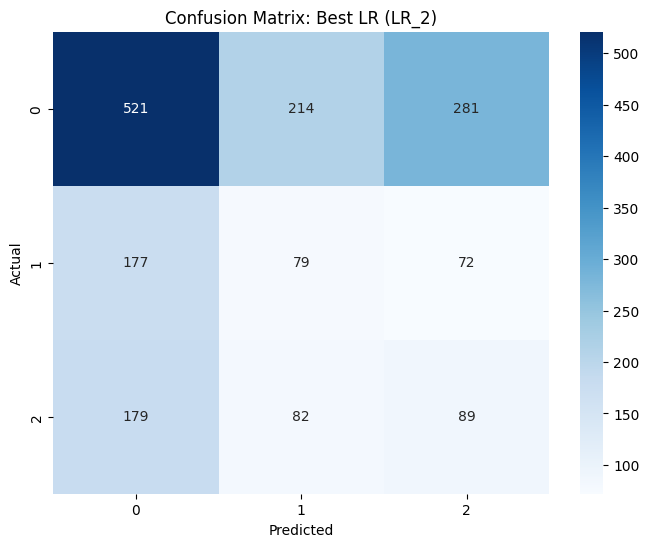


 Training LR_3


,Metric,Value (%)
0,Accuracy,42.09%
1,Precision (Weighted),44.09%
2,Recall (Weighted),42.09%
3,F1-score (Weighted),42.99%



Classification Report for LR_3:
              precision    recall  f1-score   support

     Billing       0.60      0.54      0.57      1016
       Other       0.22      0.23      0.23       328
   Technical       0.20      0.24      0.22       350

    accuracy                           0.42      1694
   macro avg       0.34      0.34      0.34      1694
weighted avg       0.44      0.42      0.43      1694

New Champion for LR! Model LR_3 saved with accuracy: 42.09%


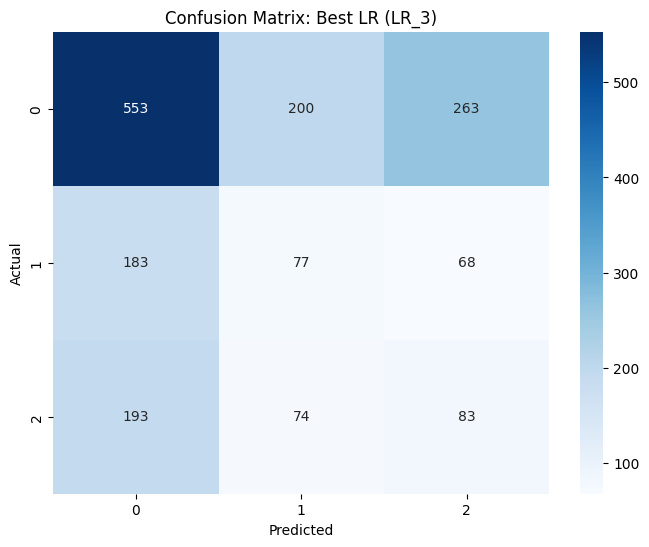


 Training SVC_1


,Metric,Value (%)
0,Accuracy,55.55%
1,Precision (Weighted),44.33%
2,Recall (Weighted),55.55%
3,F1-score (Weighted),46.38%



Classification Report for SVC_1:
              precision    recall  f1-score   support

     Billing       0.60      0.89      0.71      1016
       Other       0.24      0.07      0.11       328
   Technical       0.19      0.05      0.07       350

    accuracy                           0.56      1694
   macro avg       0.34      0.33      0.30      1694
weighted avg       0.44      0.56      0.46      1694

New Champion for SVC! Model SVC_1 saved with accuracy: 55.55%


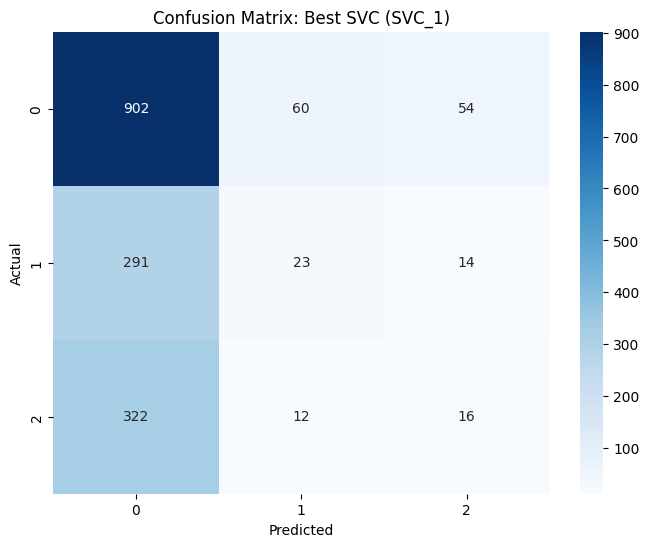


 Training SVC_2


,Metric,Value (%)
0,Accuracy,47.99%
1,Precision (Weighted),44.93%
2,Recall (Weighted),47.99%
3,F1-score (Weighted),46.20%



Classification Report for SVC_2:
              precision    recall  f1-score   support

     Billing       0.60      0.68      0.64      1016
       Other       0.22      0.17      0.19       328
   Technical       0.22      0.19      0.20       350

    accuracy                           0.48      1694
   macro avg       0.35      0.35      0.34      1694
weighted avg       0.45      0.48      0.46      1694

skipping save for SVC_2, not better than current best SVC.

 Training SVC_3


,Metric,Value (%)
0,Accuracy,47.28%
1,Precision (Weighted),45.68%
2,Recall (Weighted),47.28%
3,F1-score (Weighted),46.41%



Classification Report for SVC_3:
              precision    recall  f1-score   support

     Billing       0.61      0.65      0.63      1016
       Other       0.22      0.19      0.20       328
   Technical       0.24      0.23      0.23       350

    accuracy                           0.47      1694
   macro avg       0.36      0.35      0.35      1694
weighted avg       0.46      0.47      0.46      1694

skipping save for SVC_3, not better than current best SVC.

 Training SGD_1


,Metric,Value (%)
0,Accuracy,58.80%
1,Precision (Weighted),42.19%
2,Recall (Weighted),58.80%
3,F1-score (Weighted),45.32%



Classification Report for SGD_1:
              precision    recall  f1-score   support

     Billing       0.60      0.97      0.74      1016
       Other       0.18      0.01      0.02       328
   Technical       0.13      0.01      0.02       350

    accuracy                           0.59      1694
   macro avg       0.30      0.33      0.26      1694
weighted avg       0.42      0.59      0.45      1694

New Champion for SGD! Model SGD_1 saved with accuracy: 58.80%


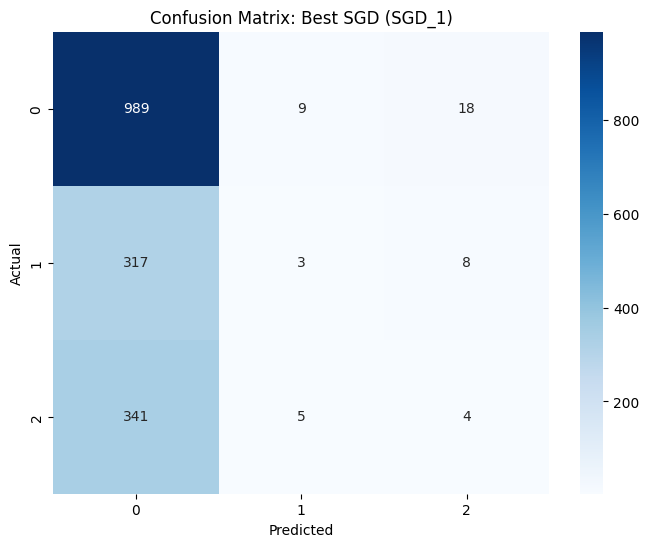


 Training SGD_2


,Metric,Value (%)
0,Accuracy,54.49%
1,Precision (Weighted),44.59%
2,Recall (Weighted),54.49%
3,F1-score (Weighted),46.67%



Classification Report for SGD_2:
              precision    recall  f1-score   support

     Billing       0.60      0.86      0.70      1016
       Other       0.27      0.09      0.14       328
   Technical       0.18      0.06      0.09       350

    accuracy                           0.54      1694
   macro avg       0.35      0.34      0.31      1694
weighted avg       0.45      0.54      0.47      1694

skipping save for SGD_2, not better than current best SGD.

 Training SGD_3


,Metric,Value (%)
0,Accuracy,47.23%
1,Precision (Weighted),45.39%
2,Recall (Weighted),47.23%
3,F1-score (Weighted),46.19%



Classification Report for SGD_3:
              precision    recall  f1-score   support

     Billing       0.60      0.65      0.62      1016
       Other       0.23      0.18      0.20       328
   Technical       0.24      0.23      0.23       350

    accuracy                           0.47      1694
   macro avg       0.36      0.35      0.35      1694
weighted avg       0.45      0.47      0.46      1694

skipping save for SGD_3, not better than current best SGD.

 Training SGD_4


,Metric,Value (%)
0,Accuracy,45.87%
1,Precision (Weighted),43.01%
2,Recall (Weighted),45.87%
3,F1-score (Weighted),44.12%



Classification Report for SGD_4:
              precision    recall  f1-score   support

     Billing       0.59      0.66      0.62      1016
       Other       0.18      0.10      0.13       328
   Technical       0.20      0.21      0.20       350

    accuracy                           0.46      1694
   macro avg       0.32      0.32      0.32      1694
weighted avg       0.43      0.46      0.44      1694

skipping save for SGD_4, not better than current best SGD.

 Training CNB_1


,Metric,Value (%)
0,Accuracy,55.61%
1,Precision (Weighted),45.89%
2,Recall (Weighted),55.61%
3,F1-score (Weighted),47.32%



Classification Report for CNB_1:
              precision    recall  f1-score   support

     Billing       0.60      0.88      0.71      1016
       Other       0.27      0.07      0.12       328
   Technical       0.23      0.08      0.11       350

    accuracy                           0.56      1694
   macro avg       0.37      0.34      0.31      1694
weighted avg       0.46      0.56      0.47      1694

New Champion for CNB! Model CNB_1 saved with accuracy: 55.61%


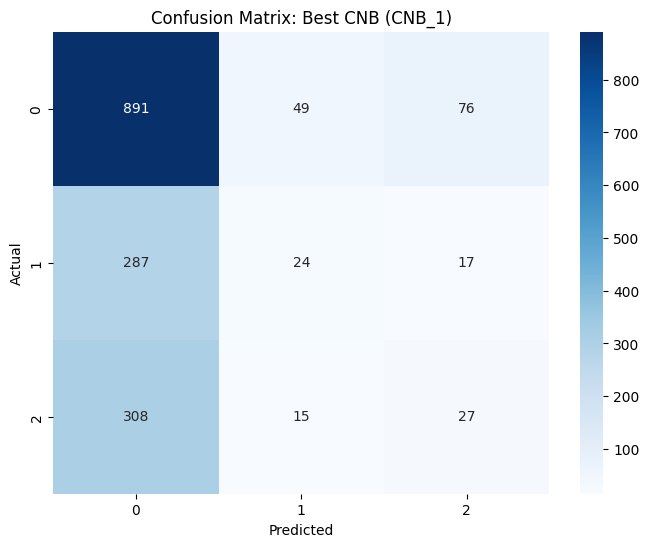


 Training CNB_2


,Metric,Value (%)
0,Accuracy,46.04%
1,Precision (Weighted),44.40%
2,Recall (Weighted),46.04%
3,F1-score (Weighted),45.15%



Classification Report for CNB_2:
              precision    recall  f1-score   support

     Billing       0.59      0.64      0.61      1016
       Other       0.22      0.20      0.21       328
   Technical       0.22      0.20      0.21       350

    accuracy                           0.46      1694
   macro avg       0.34      0.34      0.34      1694
weighted avg       0.44      0.46      0.45      1694

skipping save for CNB_2, not better than current best CNB.

 Training CNB_3


,Metric,Value (%)
0,Accuracy,38.78%
1,Precision (Weighted),43.68%
2,Recall (Weighted),38.78%
3,F1-score (Weighted),40.54%



Classification Report for CNB_3:
              precision    recall  f1-score   support

     Billing       0.58      0.45      0.51      1016
       Other       0.21      0.29      0.24       328
   Technical       0.22      0.29      0.25       350

    accuracy                           0.39      1694
   macro avg       0.34      0.34      0.34      1694
weighted avg       0.44      0.39      0.41      1694

skipping save for CNB_3, not better than current best CNB.

 Training CNB_4


...


Classification Report for CNB_4:
              precision    recall  f1-score   support

     Billing       0.57      0.46      0.51      1016
       Other       0.21      0.28      0.24       328
   Technical       0.20      0.25      0.23       350

    accuracy                           0.38      1694
   macro avg       0.33      0.33      0.33      1694
weighted avg       0.43      0.38      0.40      1694

skipping save for CNB_4, not better than current best CNB.

 Training MNB_1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Value (%)
0,Accuracy,59.98%
1,Precision (Weighted),35.97%
2,Recall (Weighted),59.98%
3,F1-score (Weighted),44.97%



Classification Report for MNB_1:
              precision    recall  f1-score   support

     Billing       0.60      1.00      0.75      1016
       Other       0.00      0.00      0.00       328
   Technical       0.00      0.00      0.00       350

    accuracy                           0.60      1694
   macro avg       0.20      0.33      0.25      1694
weighted avg       0.36      0.60      0.45      1694

New Champion for MNB! Model MNB_1 saved with accuracy: 59.98%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


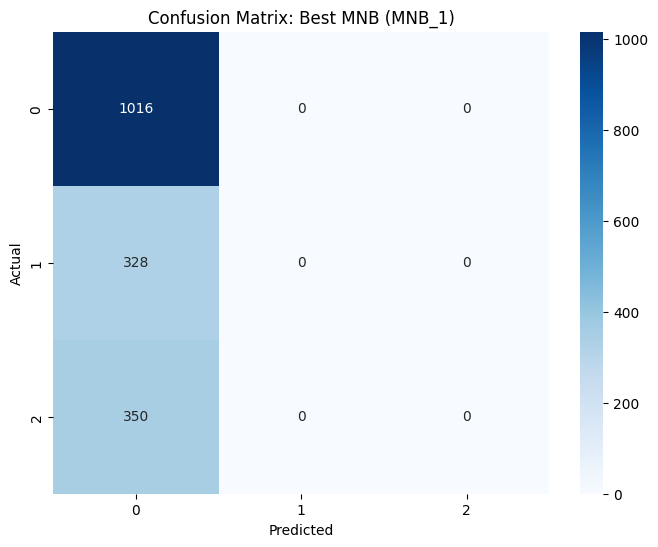


 Training MNB_2


,Metric,Value (%)
0,Accuracy,59.68%
1,Precision (Weighted),42.21%
2,Recall (Weighted),59.68%
3,F1-score (Weighted),45.11%



Classification Report for MNB_2:
              precision    recall  f1-score   support

     Billing       0.60      0.99      0.75      1016
       Other       0.14      0.00      0.01       328
   Technical       0.17      0.00      0.01       350

    accuracy                           0.60      1694
   macro avg       0.30      0.33      0.25      1694
weighted avg       0.42      0.60      0.45      1694

skipping save for MNB_2, not better than current best MNB.

 Training MNB_3


,Metric,Value (%)
0,Accuracy,54.78%
1,Precision (Weighted),44.32%
2,Recall (Weighted),54.78%
3,F1-score (Weighted),46.40%



Classification Report for MNB_3:
              precision    recall  f1-score   support

     Billing       0.59      0.87      0.71      1016
       Other       0.23      0.06      0.10       328
   Technical       0.21      0.07      0.10       350

    accuracy                           0.55      1694
   macro avg       0.34      0.33      0.30      1694
weighted avg       0.44      0.55      0.46      1694

skipping save for MNB_3, not better than current best MNB.

 Training MNB_4


,Metric,Value (%)
0,Accuracy,52.48%
1,Precision (Weighted),44.18%
2,Recall (Weighted),52.48%
3,F1-score (Weighted),46.55%



Classification Report for MNB_4:
              precision    recall  f1-score   support

     Billing       0.60      0.81      0.69      1016
       Other       0.21      0.10      0.13       328
   Technical       0.21      0.10      0.13       350

    accuracy                           0.52      1694
   macro avg       0.34      0.33      0.32      1694
weighted avg       0.44      0.52      0.47      1694

skipping save for MNB_4, not better than current best MNB.

 Training RF_1


,Metric,Value (%)
0,Accuracy,60.04%
1,Precision (Weighted),47.84%
2,Recall (Weighted),60.04%
3,F1-score (Weighted),45.43%



Classification Report for RF_1:
              precision    recall  f1-score   support

     Billing       0.60      1.00      0.75      1016
       Other       0.00      0.00      0.00       328
   Technical       0.57      0.01      0.02       350

    accuracy                           0.60      1694
   macro avg       0.39      0.34      0.26      1694
weighted avg       0.48      0.60      0.45      1694

New Champion for RF! Model RF_1 saved with accuracy: 60.04%


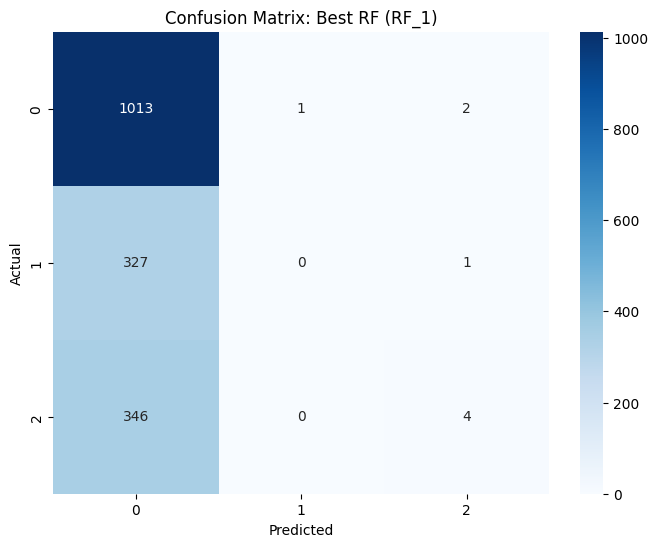


 Training RF_2


,Metric,Value (%)
0,Accuracy,58.21%
1,Precision (Weighted),44.43%
2,Recall (Weighted),58.21%
3,F1-score (Weighted),46.25%



Classification Report for RF_2:
              precision    recall  f1-score   support

     Billing       0.60      0.95      0.74      1016
       Other       0.15      0.02      0.03       328
   Technical       0.26      0.04      0.07       350

    accuracy                           0.58      1694
   macro avg       0.34      0.34      0.28      1694
weighted avg       0.44      0.58      0.46      1694

skipping save for RF_2, not better than current best RF.

 Training RF_3


,Metric,Value (%)
0,Accuracy,58.21%
1,Precision (Weighted),44.42%
2,Recall (Weighted),58.21%
3,F1-score (Weighted),46.25%



Classification Report for RF_3:
              precision    recall  f1-score   support

     Billing       0.60      0.95      0.74      1016
       Other       0.12      0.02      0.03       328
   Technical       0.29      0.04      0.07       350

    accuracy                           0.58      1694
   macro avg       0.34      0.34      0.28      1694
weighted avg       0.44      0.58      0.46      1694

skipping save for RF_3, not better than current best RF.

 Training XGB_1
❌ XGB_1 Failed: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['Billing' 'Other' 'Technical']

 Training XGB_2
❌ XGB_2 Failed: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['Billing' 'Other' 'Technical']

 Training XGB_3
❌ XGB_3 Failed: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['Billing' 'Other' 'Technical']

 Training GB_1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Value (%)
0,Accuracy,59.98%
1,Precision (Weighted),44.02%
2,Recall (Weighted),59.98%
3,F1-score (Weighted),45.53%



Classification Report for GB_1:
              precision    recall  f1-score   support

     Billing       0.60      1.00      0.75      1016
       Other       0.00      0.00      0.00       328
   Technical       0.38      0.01      0.03       350

    accuracy                           0.60      1694
   macro avg       0.33      0.34      0.26      1694
weighted avg       0.44      0.60      0.46      1694

New Champion for GB! Model GB_1 saved with accuracy: 59.98%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


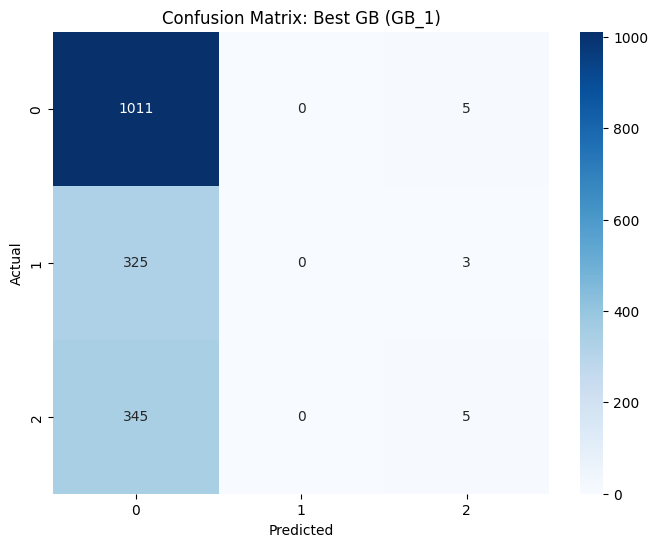


 Training GB_2


,Metric,Value (%)
0,Accuracy,58.09%
1,Precision (Weighted),43.89%
2,Recall (Weighted),58.09%
3,F1-score (Weighted),45.62%



Classification Report for GB_2:
              precision    recall  f1-score   support

     Billing       0.60      0.95      0.73      1016
       Other       0.19      0.01      0.02       328
   Technical       0.21      0.03      0.06       350

    accuracy                           0.58      1694
   macro avg       0.33      0.33      0.27      1694
weighted avg       0.44      0.58      0.46      1694

skipping save for GB_2, not better than current best GB.

 Training DT_1


,Metric,Value (%)
0,Accuracy,59.09%
1,Precision (Weighted),41.30%
2,Recall (Weighted),59.09%
3,F1-score (Weighted),45.45%



Classification Report for DT_1:
              precision    recall  f1-score   support

     Billing       0.60      0.98      0.74      1016
       Other       0.00      0.00      0.00       328
   Technical       0.26      0.02      0.04       350

    accuracy                           0.59      1694
   macro avg       0.29      0.33      0.26      1694
weighted avg       0.41      0.59      0.45      1694

New Champion for DT! Model DT_1 saved with accuracy: 59.09%


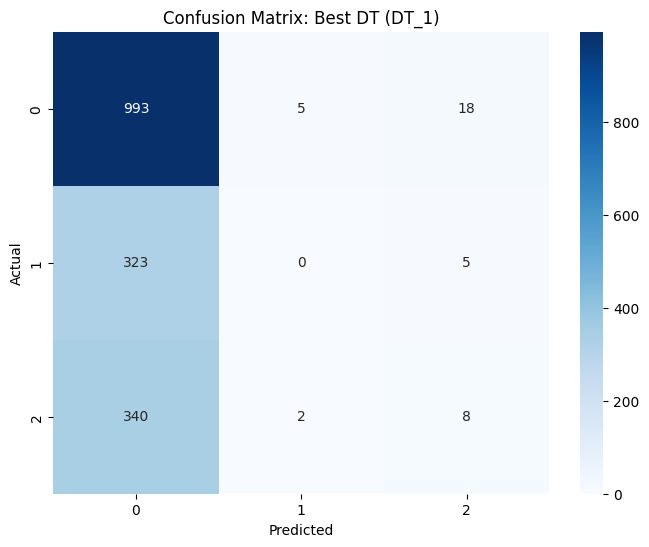


 Training DT_2


,Metric,Value (%)
0,Accuracy,22.96%
1,Precision (Weighted),44.98%
2,Recall (Weighted),22.96%
3,F1-score (Weighted),16.81%



Classification Report for DT_2:
              precision    recall  f1-score   support

     Billing       0.60      0.07      0.13      1016
       Other       0.20      0.86      0.32       328
   Technical       0.24      0.09      0.13       350

    accuracy                           0.23      1694
   macro avg       0.35      0.34      0.19      1694
weighted avg       0.45      0.23      0.17      1694

skipping save for DT_2, not better than current best DT.

 Training ADA_1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Value (%)
0,Accuracy,59.68%
1,Precision (Weighted),41.21%
2,Recall (Weighted),59.68%
3,F1-score (Weighted),45.42%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report for ADA_1:
              precision    recall  f1-score   support

     Billing       0.60      0.99      0.75      1016
       Other       0.00      0.00      0.00       328
   Technical       0.25      0.01      0.03       350

    accuracy                           0.60      1694
   macro avg       0.28      0.33      0.26      1694
weighted avg       0.41      0.60      0.45      1694

New Champion for ADA! Model ADA_1 saved with accuracy: 59.68%


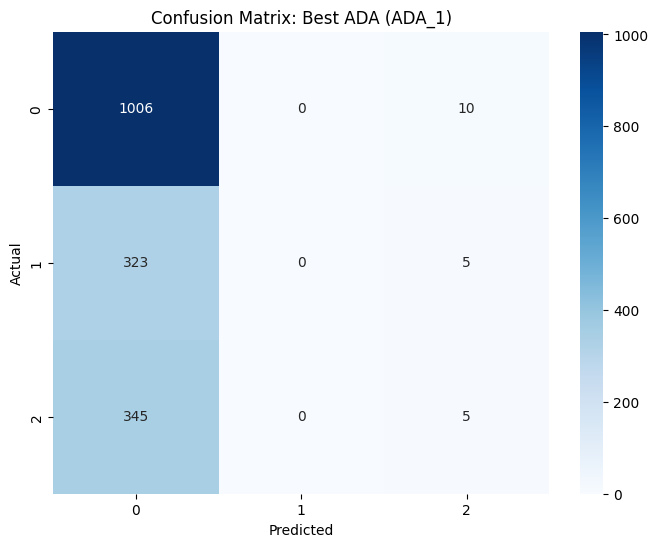


 Training ADA_2


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Value (%)
0,Accuracy,59.74%
1,Precision (Weighted),41.89%
2,Recall (Weighted),59.74%
3,F1-score (Weighted),45.30%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report for ADA_2:
              precision    recall  f1-score   support

     Billing       0.60      0.99      0.75      1016
       Other       0.00      0.00      0.00       328
   Technical       0.29      0.01      0.02       350

    accuracy                           0.60      1694
   macro avg       0.30      0.33      0.26      1694
weighted avg       0.42      0.60      0.45      1694

New Champion for ADA! Model ADA_2 saved with accuracy: 59.74%


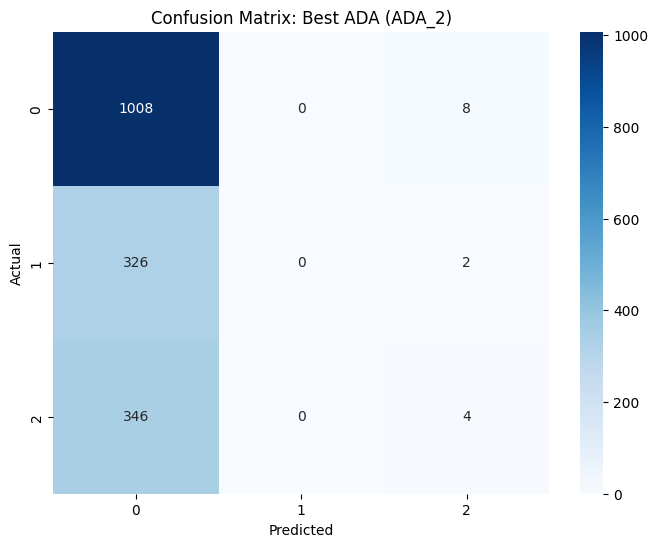


 Training KNN_1


,Metric,Value (%)
0,Accuracy,51.36%
1,Precision (Weighted),44.79%
2,Recall (Weighted),51.36%
3,F1-score (Weighted),46.86%



Classification Report for KNN_1:
              precision    recall  f1-score   support

     Billing       0.60      0.77      0.68      1016
       Other       0.20      0.08      0.11       328
   Technical       0.24      0.18      0.20       350

    accuracy                           0.51      1694
   macro avg       0.35      0.34      0.33      1694
weighted avg       0.45      0.51      0.47      1694

New Champion for KNN! Model KNN_1 saved with accuracy: 51.36%


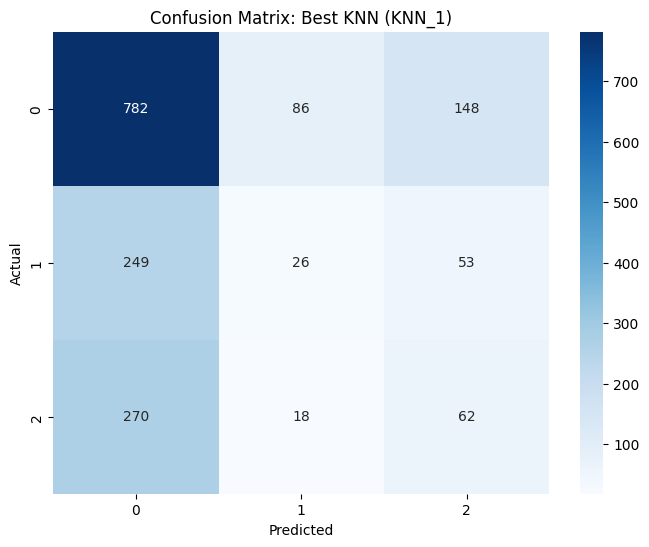


 Training KNN_2


,Metric,Value (%)
0,Accuracy,53.60%
1,Precision (Weighted),45.50%
2,Recall (Weighted),53.60%
3,F1-score (Weighted),47.66%



Classification Report for KNN_2:
              precision    recall  f1-score   support

     Billing       0.60      0.82      0.70      1016
       Other       0.20      0.07      0.11       328
   Technical       0.26      0.15      0.19       350

    accuracy                           0.54      1694
   macro avg       0.36      0.35      0.33      1694
weighted avg       0.46      0.54      0.48      1694

New Champion for KNN! Model KNN_2 saved with accuracy: 53.60%


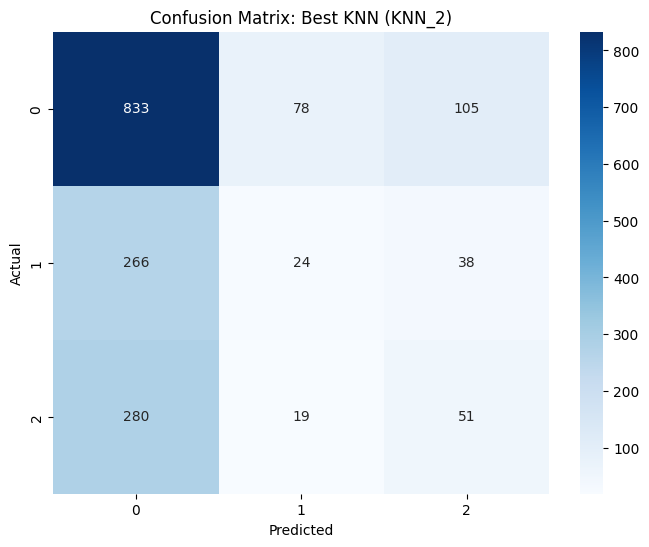


 Training KNN_3


,Metric,Value (%)
0,Accuracy,54.37%
1,Precision (Weighted),45.31%
2,Recall (Weighted),54.37%
3,F1-score (Weighted),47.34%



Classification Report for KNN_3:
              precision    recall  f1-score   support

     Billing       0.61      0.85      0.71      1016
       Other       0.22      0.05      0.08       328
   Technical       0.23      0.13      0.16       350

    accuracy                           0.54      1694
   macro avg       0.35      0.34      0.32      1694
weighted avg       0.45      0.54      0.47      1694

New Champion for KNN! Model KNN_3 saved with accuracy: 54.37%


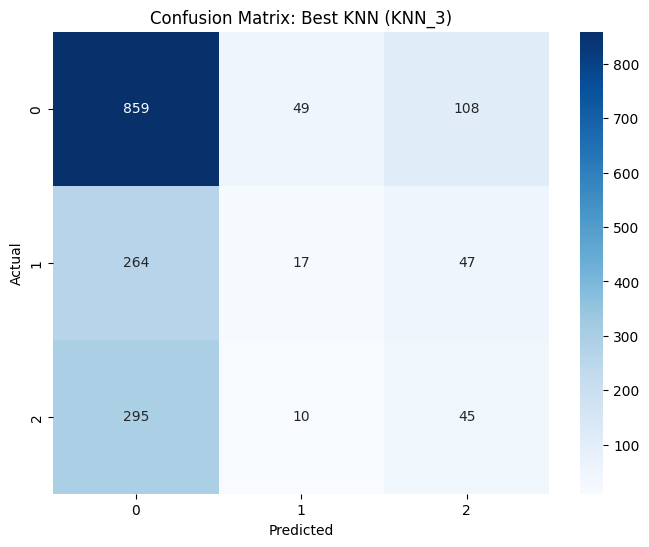

In [46]:
import joblib
import os

# Folder to save models
if not os.path.exists('best_models'):
    os.makedirs('best_models')

final_results = {}
best_family_score = {}
all_predictions = {}

for name, model in all_models.items():

    family_name = name.split('_')[0]

    try:
        y_pred, acc = train_and_evaluate(name, model, X_train, y_train, X_test, y_test)

        final_results[name] = acc
        all_predictions[name] = y_pred

        if family_name not in best_family_score or acc > best_family_score[family_name]:

            best_family_score[family_name] = acc

            # Save best model from it family

            model_path = f'best_models/best_{family_name}_model.pkl'
            joblib.dump(model, model_path)

            print(f"New Champion for {family_name}! Model {name} saved with accuracy: {acc*100:.2f}%")

            plot_conf_matrix(y_test, y_pred, f"Best {family_name} ({name})")
        else:
            print(f"skipping save for {name}, not better than current best {family_name}.")

    except Exception as e:
        print(f"❌ {name} Failed: {e}")

In [ ]:
from xgboost import XGBClassifier

xgb_best = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6)
xgb_best.fit(X_train, y_train_enc)

y_pred_xgb = le.inverse_transform(xgb_best.predict(X_test))

print("XGBoost Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))

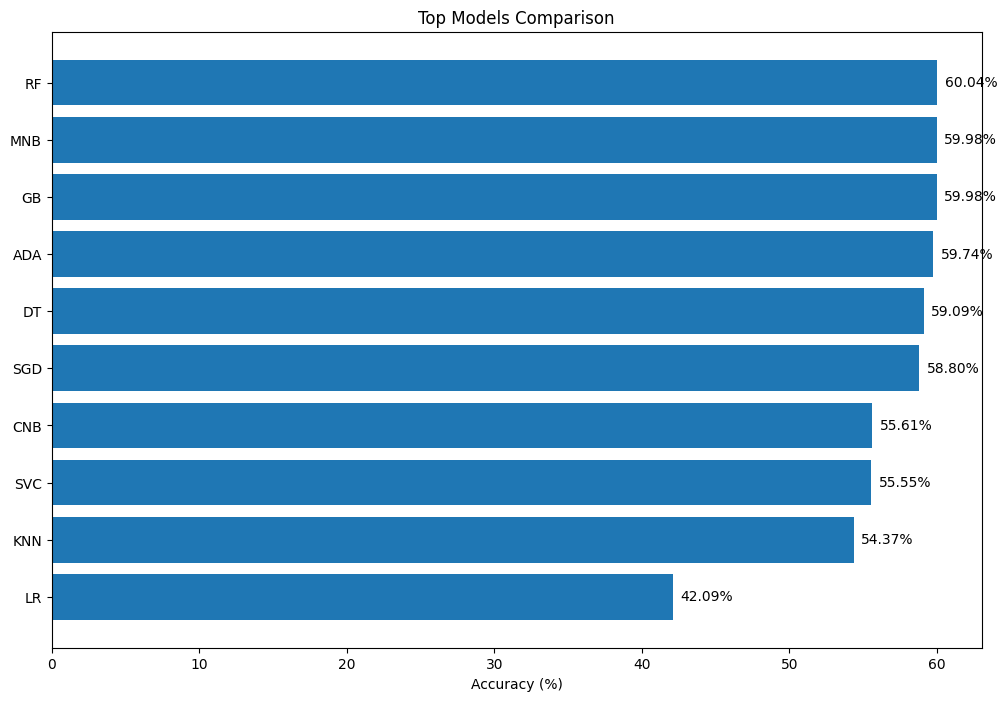

In [50]:
# Display results
import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_comparison(results_dict):

    sorted_res = sorted(results_dict.items(), key=lambda x: x[1], reverse=True)[:10] # توب 10
    names = [x[0] for x in sorted_res]
    scores = [x[1] * 100 for x in sorted_res]

    plt.figure(figsize=(12, 8))
    bars = plt.barh(names[::-1], scores[::-1])

    plt.xlabel('Accuracy (%)')
    plt.title('Top Models Comparison')

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', va='center')

    plt.show()

best_models_only = {}
for name, acc in final_results.items():
    family = name.split('_')[0]
    if family not in best_models_only or acc > best_models_only[family]:
        best_models_only[family] = acc


plot_model_comparison(best_models_only)

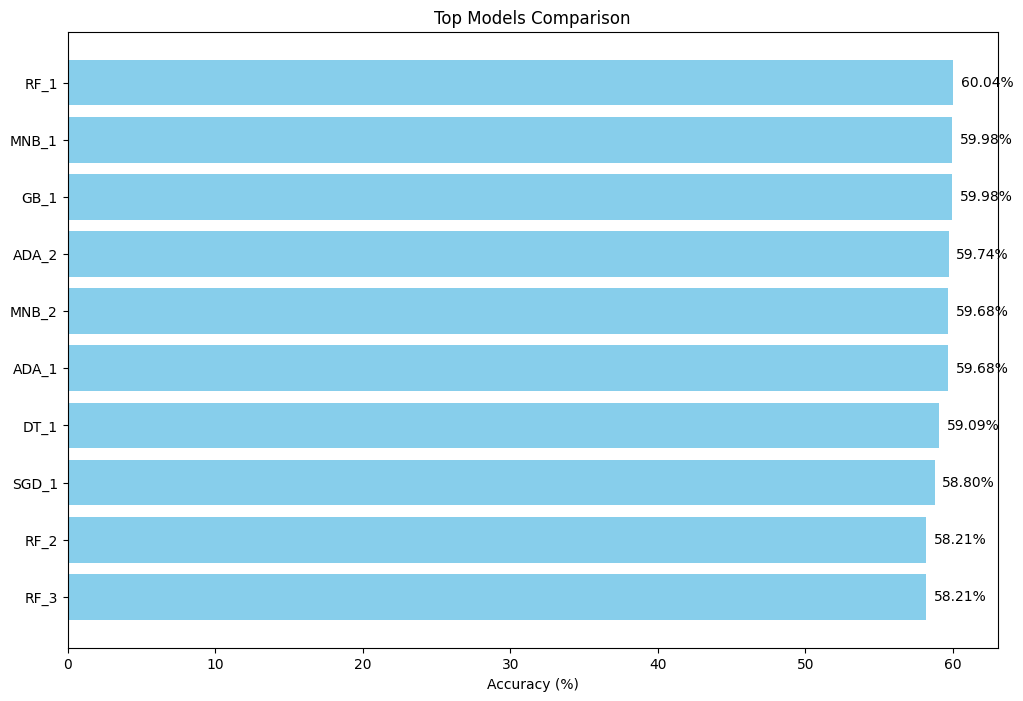

In [51]:
# Display all Results

def plot_model_comparison(results_dict):

    sorted_res = sorted(results_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    names = [x[0] for x in sorted_res]
    scores = [x[1] * 100 for x in sorted_res]

    plt.figure(figsize=(12, 8))
    bars = plt.barh(names[::-1], scores[::-1], color='skyblue')

    plt.xlabel('Accuracy (%)')
    plt.title('Top Models Comparison')

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', va='center')

    plt.show()

plot_model_comparison(final_results)

## **Gradio Demo Application**

In [53]:
import gradio as gr
import joblib

BEST_MODEL_PATH = '/content/best_models/best_RF_model.pkl'
TFIDF_PATH = '/content/tfidf.pkl'
LE_PATH = '/content/label_encoder.pkl'

def predict_ticket_category(subject, description):
    full_text = f"{subject} {description}"

    processed_text = clean_text(full_text)

    vectorized_text = tfidf.transform([processed_text])

    prediction = model.predict(vectorized_text)

    try:
        category = le.inverse_transform(prediction)[0]
    except:
        category = prediction[0]

    return category

# Build Gradio Interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🎫 Customer Support Ticket Classifier (Best Model)")
    gr.Markdown(f"Currently running on: **{BEST_MODEL_PATH.split('/')[-1]}**")

    with gr.Row():
        with gr.Column():
            sub_input = gr.Textbox(lines=2, label="Ticket Subject", placeholder="e.g., VPN not connecting")
            desc_input = gr.Textbox(lines=5, label="Ticket Description", placeholder="Enter the issue details...")
            submit_btn = gr.Button("🚀 Classify Ticket", variant="primary")

        with gr.Column():
            output_text = gr.Textbox(label="Predicted Category", interactive=False)

    gr.Examples(
        examples=[
            ["Internet connection issue", "My router is not connecting to the internet despite several restarts."],
            ["Overcharged on invoice", "I noticed an extra $20 on my billing statement this month."],
            ["Can't access my account", "I forgot my password and the reset link is not arriving."]
        ],
        inputs=[sub_input, desc_input]
    )

    submit_btn.click(fn=predict_ticket_category, inputs=[sub_input, desc_input], outputs=output_text)

# Running
demo.launch(share=True)

/tmp/ipykernel_1845/955371299.py:35: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4672f0376ad31c23f5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
